In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

dados = pd.read_csv('ExpVinho.csv', sep="\t")
dados.head()

,Id,País,1970,1970.1,1971,1971.1,1972,1972.1,1973,1973.1,...,2020,2020.1,2021,2021.1,2022,2022.1,2023,2023.1,2024,2024.1
0,1,Afeganistão,0,0,0,0,0,0,0,0,...,0,0,11,46,0,0,0,0,0,0
1,2,África do Sul,0,0,0,0,0,0,0,0,...,4,21,0,0,0,0,117,698,103,1783
2,3,"Alemanha, República Democrática",0,0,0,0,4168,2630,12000,8250,...,6261,32605,2698,6741,7630,45367,4806,31853,6666,48095
3,4,Angola,0,0,0,0,0,0,0,0,...,0,0,0,0,4068,4761,0,0,0,0
4,5,Anguilla,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [2]:
# Passo 2: Selecionar as colunas para os anos
colunas_ano = [col for col in dados.columns if col not in ["Id", "País"] and not col.endswith(".1")]
colunas_quantidade = [col for col in dados.columns if col.endswith(".1")]

# Ordenar as colunas assumindo que são numéricas
colunas_ano = sorted(colunas_ano, key=lambda x: int(x))
colunas_quantidade = sorted(colunas_quantidade, key=lambda x: int(x.split('.')[0]))

# Passo 3: Transformar de "wide" para "long"
dados_ano = dados.melt(id_vars=["País"], value_vars=colunas_ano,
                 var_name="ano", value_name="quantidade")

dados_quantidade = dados.melt(id_vars=["País"], value_vars=colunas_quantidade,
                        var_name="ano", value_name="valor")
# Remove o sufixo ".1" da coluna "ano" para poder fazer a junção
dados_quantidade["ano"] = dados_quantidade["ano"].str.replace(".1", "", regex=False)

# Passo 4: Mesclar os DataFrames
dados_merged = pd.merge(dados_ano, dados_quantidade, on=["País", "ano"])

# Passo 5: Reorganizar as colunas conforme solicitado
dados_compilados = dados_merged[["ano", "País", "quantidade", "valor"]]

print(dados_compilados.head())

    ano                             País  quantidade  valor
0  1970                      Afeganistão           0      0
1  1970                    África do Sul           0      0
2  1970  Alemanha, República Democrática           0      0
3  1970                           Angola           0      0
4  1970                         Anguilla           0      0


In [3]:
dados_compilados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7755 entries, 0 to 7754
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ano         7755 non-null   object
 1   País        7755 non-null   object
 2   quantidade  7755 non-null   int64 
 3   valor       7755 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 242.5+ KB


In [4]:
dados_compilados['ano'] = pd.to_numeric(dados_compilados['ano'], errors='coerce')

In [5]:
dados_compilados['ano'].unique()

array([1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980,
       1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
       1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002,
       2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024])

In [6]:
# Verificando valores nulos
dados_compilados.isna().sum()

ano           0
País          0
quantidade    0
valor         0
dtype: int64

In [7]:
# Verificando qtd. de registros duplicados
dados_compilados.duplicated().sum()

np.int64(0)

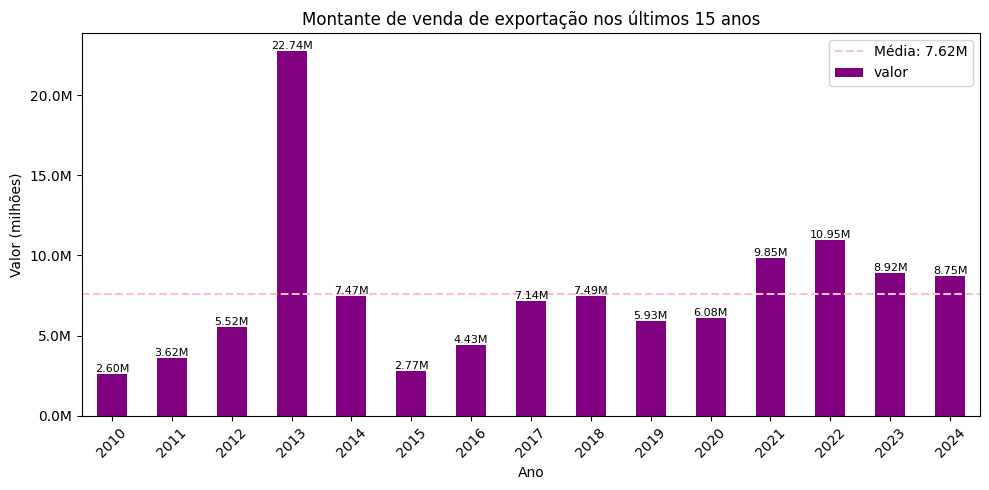

In [21]:
# Calcula os dados e a média
dados_5anos = dados_compilados[dados_compilados['ano'] >= 2010].groupby('ano')['valor'].sum().reset_index()
media_valor = dados_5anos['valor'].mean()

# Cria o gráfico de barras
ax = dados_5anos.plot(x='ano', y='valor', kind='bar', figsize=(10, 5), legend=False, color='purple')

# Adiciona rótulos de valor nas barras (em milhões)
for i, v in enumerate(dados_5anos['valor']):
    ax.text(i, v, f'{v/1_000_000:.2f}M', ha='center', va='bottom', fontsize=8, rotation=0)

# Adiciona a linha de média
ax.axhline(media_valor, color='pink', linestyle='--', label=f'Média: {media_valor/1_000_000:.2f}M')

# Formata o eixo Y também em milhões
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))

# Melhora layout
plt.ylabel('Valor (milhões)')
plt.xlabel('Ano')
plt.title('Montante de venda de exportação nos últimos 15 anos')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
dados_ordenados = dados_compilados[(dados_compilados['ano'] == 2013) & (dados_compilados['valor']>=1)].groupby('País', as_index=False)['valor'].sum()
dados_ordenados = dados_ordenados.sort_values('valor', ascending=False)

dados_ordenados


,País,valor
30,Rússia,14795694
12,Espanha,3748940
13,Estados Unidos,786556
24,Paraguai,680828
19,Japão,429088
29,Reino Unido,305005
14,Finlândia,283114
8,China,279956
0,"Alemanha, República Democrática",265978
25,Países Baixos,255690


In [16]:
dados_ordenados = dados_compilados[dados_compilados['valor']>=1].groupby('País', as_index=False)['valor'].mean()
dados_ordenados = dados_ordenados.sort_values('valor', ascending=False)

dados_ordenados.set_option('display.float_format', '{:.2f}'.format)


dados_ordenados

AttributeError: 'DataFrame' object has no attribute 'set_option'

In [17]:
import pandas as pd

# Configura o pandas para exibir números com 2 casas decimais e sem notação científica
pd.set_option('display.float_format', '{:.2f}'.format)

# Seu código normalmente
dados_ordenados = dados_compilados[dados_compilados['valor'] >= 1].groupby('País', as_index=False)['valor'].mean()
dados_ordenados = dados_ordenados.sort_values('valor', ascending=False)

# Exibe o resultado
print(dados_ordenados)


               País      valor
112          Rússia 1851052.50
102        Paraguai 1749914.33
50   Estados Unidos 1319681.87
49          Espanha  352177.82
29            China  270722.32
..              ...        ...
55            Gabão      18.00
71        Indonésia      18.00
129        Toquelau      10.00
83            Macau       6.00
133          Tuvalu       4.00

[141 rows x 2 columns]
